In [67]:
# 导入必要的库
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from datetime import datetime

# 设置中文字体和绘图样式
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

In [68]:
df_weather = pd.read_csv('../data/raw/气象总表.csv', encoding='utf-8')
df_market = pd.read_csv('../data/raw/市场边界_出清价格总表.csv', encoding='utf-8')

print(df_weather.shape) 
print(df_market.shape)

(7272, 318)
(7272, 26)


In [69]:
def calculate_zero_rate(df, name):
    # 1. 将缺失值 (NaN) 填充为 0
    df_filled = df.fillna(0)
    
    # 2. 统计 0 的数量 (包括原本的 0 和填充进来的 0)
    # 注意：这里只统计数值型列，避免对字符串列报错
    zero_counts = (df_filled == 0).sum()
    
    # 3. 计算总行数
    total_rows = len(df_filled)
    
    # 4. 计算含 0 率
    zero_rate = (zero_counts / total_rows) * 100
    
    print(f"\n=== {name} 含0率统计 (缺失值视为0) ===")
    # 只显示含0率大于0的列，并按比例降序排列
    result = zero_rate[zero_rate > 0].sort_values(ascending=False)
    
    if result.empty:
        print("无含0列")
    else:
        print(result.round(2)) # 保留两位小数

# 执行统计
calculate_zero_rate(df_weather, "气象数据集")
calculate_zero_rate(df_market, "市场数据集")


=== 气象数据集 含0率统计 (缺失值视为0) ===
宜昌市-降雨量-源3-预测    79.47
黄冈市-降雨量-源3-预测    79.41
襄阳市-降雨量-源2-预测    78.81
荆州市-降雨量-源4-预测    78.73
襄阳市-降雨量-源4-预测    78.53
                 ...  
荆门市-温度-源6-预测      0.04
荆州市-温度-源6-预测      0.04
荆州市-风速-源5-预测      0.03
武汉市-温度-源6-预测      0.01
黄冈市-温度-源6-预测      0.01
Length: 291, dtype: float64

=== 市场数据集 含0率统计 (缺失值视为0) ===
是否周末                71.62
是否高峰时段              66.67
是否夜间                62.50
光伏出力-实时             30.02
光伏出力-日前             28.09
水电出力-实时             11.43
系统负荷-实时             10.49
非市场化机组出力-实时         10.40
小时                   4.17
平均出清价格-日前（元/MWh）     3.92
平均出清价格-实时（元/MWh）     2.02
风电出力-实时              1.35
风电出力-日前              0.66
联络线计划-日前             0.66
联络线计划-实时             0.33
dtype: float64


In [70]:
def remove_high_zero_cols(df, name, threshold=0.8):
    # 1. 将缺失值填充为 0
    df_filled = df.fillna(0)
    
    # 2. 计算含 0 率
    # (df_filled == 0) 生成布尔表，.mean() 计算 True 的比例 (即含0率)
    zero_rate = (df_filled == 0).mean()
    
    # 3. 筛选出含0率大于阈值的列
    cols_to_drop = zero_rate[zero_rate > threshold].index.tolist()
    
    # 4. 执行删除
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"✅ [{name}] 已删除 {len(cols_to_drop)} 个含0率 > {threshold*100}% 的列")
        print(cols_to_drop)
    else:
        print(f"✅ [{name}] 无含0率 > {threshold*100}% 的列")
        
    return df

# 执行清洗 (删除含0率大于80%的列)
df_weather = remove_high_zero_cols(df_weather, "气象数据集", threshold=0.8)
df_market = remove_high_zero_cols(df_market, "市场数据集", threshold=0.8)

✅ [气象数据集] 无含0率 > 80.0% 的列
✅ [市场数据集] 无含0率 > 80.0% 的列


In [71]:
# 检查缺失值
missing_data = df_weather.isnull().sum()
missing_percentage = (missing_data / len(df_weather)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

missing_data = df_market.isnull().sum()
missing_percentage = (missing_data / len(df_market)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

=== 缺失值统计 ===


,缺失数量,缺失比例(%)
黄冈市-总云量-源2-预测,922,12.68
武汉市-总云量-源2-预测,907,12.47
荆门市-总云量-源2-预测,896,12.32
孝感市-总云量-源2-预测,896,12.32
随州市-总云量-源2-预测,887,12.20
...,...,...
荆州市-温度-源7-实际,77,1.06
武汉市-风速-源7-实际,77,1.06
武汉市-温度-源7-实际,77,1.06
武汉市-相对湿度-源7-实际,77,1.06


=== 缺失值统计 ===


,缺失数量,缺失比例(%)
水电出力-实时,825,11.34
系统负荷-实时,759,10.44
非市场化机组出力-实时,753,10.35
平均出清价格-日前（元/MWh）,216,2.97
风电出力-实时,96,1.32
光伏出力-实时,96,1.32
风电出力-日前,48,0.66
联络线计划-日前,48,0.66
光伏出力-日前,48,0.66
平均出清价格-实时（元/MWh）,48,0.66


In [72]:
def calculate_smape(y_true, y_pred):
    """
    计算对称平均绝对百分比误差 (sMAPE)
    公式: (1/n) * Σ(2 * |y_true - y_pred| / (|y_true| + |y_pred|)) * 100%
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 避免除以0的情况
    denominator = (np.abs(y_true) + np.abs(y_pred))
    mask = denominator != 0
    
    if mask.sum() == 0:
        return np.nan
    
    smape = np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100
    return smape

def calculate_rmse(y_true, y_pred):
    """
    计算均方根误差 (RMSE)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def analyze_weather_data(df_weather, city, weather_type):
    """
    分析选定城市和气象类型的不同数据源之间的相关性
    
    参数:
        df_weather: 气象数据
        city: 城市名称，如 '孝感市', '宜昌市', '武汉市', '荆州市'
        weather_type: 气象类型，如 '温度', '风速', '总云量', '相对湿度', '压强', '辐照度', '降雨量'
    
    返回:
        包含Spearman相关性、RMSE、sMAPE的结果字典
    """
    # 读取数据
    df = df_weather.copy()
    
    # 筛选出选定城市和气象类型的列
    pattern = f"{city}-{weather_type}"
    selected_cols = [col for col in df.columns if pattern in col]
    
    if len(selected_cols) == 0:
        print(f"未找到 {city} 的 {weather_type} 数据")
        return None
    
    print(f"找到以下列: {selected_cols}")
    
    # 提取数据
    data = df[selected_cols].copy()
    
    # 删除所有值都为空的行
    data = data.dropna(how='all')
    
    # 分离预测列和实际列
    pred_cols = [col for col in selected_cols if '预测' in col]
    actual_cols = [col for col in selected_cols if '实际' in col]
    
    print(f"\n预测数据源: {pred_cols}")
    print(f"实际数据源: {actual_cols}")
    
    results = {
        '预测vs预测': {},
        '预测vs实际': {},
        '实际vs实际': {}
    }
    
    # 1. 计算预测数据之间的相关性
    print(f"\n{'='*60}")
    print(f"1. 预测数据源之间的比较")
    print(f"{'='*60}")
    
    for i in range(len(pred_cols)):
        for j in range(i+1, len(pred_cols)):
            col1, col2 = pred_cols[i], pred_cols[j]
            
            # 获取有效数据（去除NaN）
            valid_data = data[[col1, col2]].dropna()
            
            if len(valid_data) < 2:
                continue
                
            # 计算Spearman相关性
            corr, p_value = spearmanr(valid_data[col1], valid_data[col2])
            
            # 计算RMSE
            rmse = calculate_rmse(valid_data[col1], valid_data[col2])
            
            # 计算sMAPE
            smape = calculate_smape(valid_data[col1], valid_data[col2])
            
            key = f"{col1} vs {col2}"
            results['预测vs预测'][key] = {
                'Spearman相关系数': corr,
                'P值': p_value,
                'RMSE': rmse,
                'sMAPE(%)': smape,
                '样本数': len(valid_data)
            }
            
            print(f"\n{col1} vs {col2}:")
            print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  sMAPE: {smape:.2f}%")
            print(f"  样本数: {len(valid_data)}")
    
    # 2. 计算预测与实际数据之间的相关性
    print(f"\n{'='*60}")
    print(f"2. 预测与实际数据之间的比较")
    print(f"{'='*60}")
    
    for pred_col in pred_cols:
        for actual_col in actual_cols:
            # 获取有效数据
            valid_data = data[[pred_col, actual_col]].dropna()
            
            if len(valid_data) < 2:
                continue
            
            # 计算Spearman相关性
            corr, p_value = spearmanr(valid_data[pred_col], valid_data[actual_col])
            
            # 计算RMSE（以实际值为基准）
            rmse = calculate_rmse(valid_data[actual_col], valid_data[pred_col])
            
            # 计算sMAPE（以实际值为基准）
            smape = calculate_smape(valid_data[actual_col], valid_data[pred_col])
            
            key = f"{pred_col} vs {actual_col}"
            results['预测vs实际'][key] = {
                'Spearman相关系数': corr,
                'P值': p_value,
                'RMSE': rmse,
                'sMAPE(%)': smape,
                '样本数': len(valid_data)
            }
            
            print(f"\n{pred_col} vs {actual_col}:")
            print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  sMAPE: {smape:.2f}%")
            print(f"  样本数: {len(valid_data)}")
    
    # 3. 计算实际数据之间的相关性
    if len(actual_cols) > 1:
        print(f"\n{'='*60}")
        print(f"3. 实际数据源之间的比较")
        print(f"{'='*60}")
        
        for i in range(len(actual_cols)):
            for j in range(i+1, len(actual_cols)):
                col1, col2 = actual_cols[i], actual_cols[j]
                
                # 获取有效数据
                valid_data = data[[col1, col2]].dropna()
                if len(valid_data) < 2:
                    print(f"  ⚠️ 重叠样本不足2个，跳过比较")
                    continue
                
                # 计算Spearman相关性
                corr, p_value = spearmanr(valid_data[col1], valid_data[col2])
                
                # 计算RMSE
                rmse = calculate_rmse(valid_data[col1], valid_data[col2])
                
                # 计算sMAPE
                smape = calculate_smape(valid_data[col1], valid_data[col2])
                
                print(f"\n{col1} vs {col2}:")
                print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
                print(f"  RMSE: {rmse:.4f}")
                print(f"  sMAPE: {smape:.2f}%")
                
                key = f"{col1} vs {col2}"
                results['实际vs实际'][key] = {
                    'Spearman相关系数': corr,
                    'P值': p_value,
                    'RMSE': rmse,
                    'sMAPE(%)': smape,
                    '样本数': len(valid_data)
                }
    
    return results


def export_results_to_excel(results, output_path):
    """
    将结果导出到Excel文件
    """
    import openpyxl
    from openpyxl.styles import Font, Alignment, PatternFill
    
    rows = []
    
    for category, comparisons in results.items():
        for comparison, metrics in comparisons.items():
            rows.append({
                '比较类型': category,
                '数据源对比': comparison,
                'Spearman相关系数': metrics['Spearman相关系数'],
                'P值': metrics['P值'],
                'RMSE': metrics['RMSE'],
                'sMAPE(%)': metrics['sMAPE(%)'],
                '样本数': metrics['样本数']
            })
    
    df_result = pd.DataFrame(rows)
    df_result.to_excel(output_path, index=False)
    print(f"\n结果已导出到: {output_path}")
    
    return df_result
  
# 选择城市和气象类型
city = "孝感市"  # 可选: 孝感市, 宜昌市, 武汉市, 荆州市等
weather_type = "辐照度"  # 可选: 温度, 风速, 总云量, 相对湿度, 压强, 辐照度, 降雨量

# 分析数据
results = analyze_weather_data(df_weather, city, weather_type)

# 导出结果到Excel
if results:
    output_path = f"../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"
    export_results_to_excel(results, output_path)

找到以下列: ['孝感市-辐照度-源2-预测', '孝感市-辐照度-源3-预测', '孝感市-辐照度-源4-预测', '孝感市-辐照度-源6-预测']

预测数据源: ['孝感市-辐照度-源2-预测', '孝感市-辐照度-源3-预测', '孝感市-辐照度-源4-预测', '孝感市-辐照度-源6-预测']
实际数据源: []

1. 预测数据源之间的比较

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源3-预测:
  Spearman相关系数: 0.9951 (p值: 0.0000)
  RMSE: 614977.3177
  sMAPE: 11.11%
  样本数: 7057

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源4-预测:
  Spearman相关系数: 0.8918 (p值: 0.0000)
  RMSE: 138.3169
  sMAPE: 87.76%
  样本数: 7031

孝感市-辐照度-源2-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.9010 (p值: 0.0000)
  RMSE: 131.0283
  sMAPE: 95.52%
  样本数: 7083

孝感市-辐照度-源3-预测 vs 孝感市-辐照度-源4-预测:
  Spearman相关系数: 0.8909 (p值: 0.0000)
  RMSE: 614498.6030
  sMAPE: 88.95%
  样本数: 7068

孝感市-辐照度-源3-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.9004 (p值: 0.0000)
  RMSE: 612250.5349
  sMAPE: 96.63%
  样本数: 7120

孝感市-辐照度-源4-预测 vs 孝感市-辐照度-源6-预测:
  Spearman相关系数: 0.9525 (p值: 0.0000)
  RMSE: 86.1599
  sMAPE: 64.32%
  样本数: 7132

2. 预测与实际数据之间的比较

结果已导出到: ../results/logs/孝感市_辐照度_数据源对比分析.xlsx


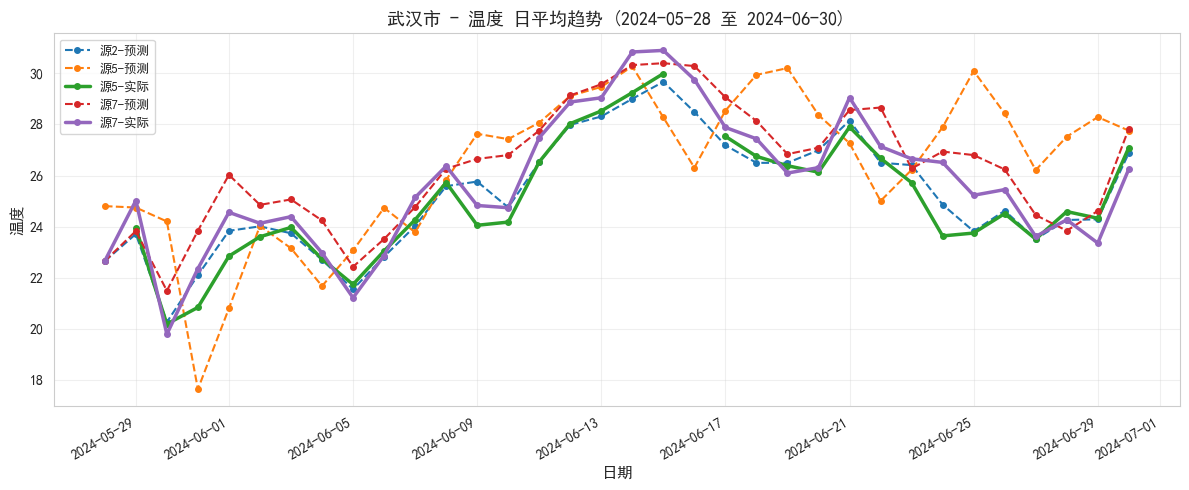

In [73]:
def plot_weather_timeseries(df_weather, city, weather_type, 
                            data_sources=None,
                            plot_type='both',
                            start_date=None,
                            end_date=None):
    """
    绘制气象数据时间序列趋势曲线（按日平均）
    
    参数:
        df_weather: 气象数据    
        city: 城市名称，如 '武汉市'
        weather_type: 气象类型，如 '温度'
        data_sources: 数据源列表，如 ['源2', '源5']，None表示全部
        plot_type: 'forecast'=仅预测, 'actual'=仅实际, 'both'=两者都画
        start_date: 起始日期 '2024-05-28'
        end_date: 结束日期 '2024-06-01'
    """
    
    # 读取数据
    df = df_weather.copy()
    df['日期'] = pd.to_datetime(df['日期'])
    
    # 日期筛选
    if start_date:
        df = df[df['日期'] >= start_date]
    if end_date:
        df = df[df['日期'] <= end_date]
    
    # 筛选列
    pattern = f"{city}-{weather_type}"
    all_cols = [col for col in df.columns if pattern in col]
    
    # 根据data_sources和plot_type筛选
    selected_cols = []
    for col in all_cols:
        # 检查数据源
        if data_sources and not any(src in col for src in data_sources):
            continue
        
        # 检查类型
        is_forecast = '预测' in col
        is_actual = '实际' in col
        
        if plot_type == 'forecast' and is_forecast:
            selected_cols.append(col)
        elif plot_type == 'actual' and is_actual:
            selected_cols.append(col)
        elif plot_type == 'both':
            selected_cols.append(col)
    
    if len(selected_cols) == 0:
        print("没有符合条件的列")
        return
    
    # 按日期计算平均值
    daily_data = df.groupby('日期')[selected_cols].mean().reset_index()
    
    # 绘制
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for col in selected_cols:
        # 简化标签
        label = col.replace(f"{city}-{weather_type}-", "")
        
        # 线型
        linestyle = '-' if '实际' in col else '--'
        linewidth = 2.5 if '实际' in col else 1.5
        
        ax.plot(daily_data['日期'], daily_data[col], 
                label=label, 
                linestyle=linestyle,
                linewidth=linewidth,
                marker='o',
                markersize=4)
    
    # 标题和标签
    title = f"{city} - {weather_type} 日平均趋势"
    if start_date and end_date:
        title += f" ({start_date} 至 {end_date})"
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('日期', fontsize=11)
    ax.set_ylabel(weather_type, fontsize=11)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_weather_timeseries(
    df_weather,
    city="武汉市",
    weather_type="温度",
    data_sources=['源2', '源5', '源7'],
    plot_type='both',
    start_date='2024-05-28',
    end_date='2024-06-30'
)

In [74]:
import re
from collections import defaultdict
from itertools import combinations

def calculate_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred))
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def parse_column_name(col_name):
    pattern = r'(.+?)-(.+?)-(源\d+)-(预测|实际)'
    match = re.match(pattern, col_name)
    if match:
        return {
            'city': match.group(1),
            'weather_type': match.group(2),
            'source': match.group(3),
            'data_type': match.group(4)
        }
    return None


def get_weather_groups(df_weather):
    groups = defaultdict(lambda: {'actual': [], 'forecast': []})
    for col in df_weather.columns:
        parsed = parse_column_name(col)
        if parsed:
            key = (parsed['city'], parsed['weather_type'])
            if parsed['data_type'] == '实际':
                groups[key]['actual'].append(col)
            else:
                groups[key]['forecast'].append(col)
    return groups


def calculate_metrics(series1, series2):
    valid_data = pd.DataFrame({'s1': series1, 's2': series2}).dropna()
    if len(valid_data) < 10:
        return None, None
    corr, _ = spearmanr(valid_data['s1'], valid_data['s2'])
    smape = calculate_smape(valid_data['s1'], valid_data['s2'])
    return corr, smape


def calculate_price_correlation(series, price_series):
    valid_data = pd.DataFrame({'s': series, 'price': price_series}).dropna()
    if len(valid_data) < 10:
        return 0
    corr, _ = spearmanr(valid_data['s'], valid_data['price'])
    return abs(corr)


def simplify_weather_features(df_weather, df_market, 
                              corr_threshold=0.80, 
                              smape_threshold=20,
                              price_col='平均出清价格-实时（元/MWh）'):
    """
    简化气象特征主函数
    """
    simplified_df = df_weather.copy()
    cols_to_drop = set()  # 使用集合存储待删除列
    
    # 对齐数据获取电价序列
    if '日期' in df_weather.columns and '日期' in df_market.columns:
        merged = pd.merge(df_weather, df_market[['日期', price_col]], 
                         on='日期', how='inner')
    else:
        merged = pd.concat([df_weather.reset_index(drop=True), 
                           df_market[price_col].reset_index(drop=True)], axis=1)
    price_series = merged[price_col]
    
    groups = get_weather_groups(df_weather)
    
    for (city, weather_type), cols in groups.items():
        actual_cols = cols['actual']
        forecast_cols = cols['forecast']
        
        # ========== 第一阶段：预测源填充实际源 ==========
        used_forecasts = set()
        
        for actual_col in actual_cols:
            best_forecast = None
            best_smape = float('inf')
            
            for forecast_col in forecast_cols:
                if forecast_col in used_forecasts or forecast_col in cols_to_drop:
                    continue
                    
                corr, smape = calculate_metrics(simplified_df[actual_col], 
                                                simplified_df[forecast_col])
                
                if corr is None:
                    continue
                
                # 满足条件时选择sMAPE最小的
                if corr > corr_threshold and smape < smape_threshold:
                    if smape < best_smape:
                        best_smape = smape
                        best_forecast = forecast_col
            
            if best_forecast:
                simplified_df[actual_col] = simplified_df[actual_col].fillna(
                    simplified_df[best_forecast]
                )
                used_forecasts.add(best_forecast)
                cols_to_drop.add(best_forecast)
        
        # ========== 第二阶段：剩余预测源之间简化（迭代处理） ==========
        while True:
            remaining_forecasts = [c for c in forecast_cols 
                                  if c not in used_forecasts and c not in cols_to_drop]
            
            if len(remaining_forecasts) <= 1:
                break
            
            # 计算与电价的相关性
            price_corrs = {col: calculate_price_correlation(simplified_df[col], price_series) 
                          for col in remaining_forecasts}
            
            # 找出所有满足条件的填充对
            fill_pairs = []
            for col1, col2 in combinations(remaining_forecasts, 2):
                corr, smape = calculate_metrics(simplified_df[col1], simplified_df[col2])
                
                if corr is None:
                    continue
                
                if corr > corr_threshold and smape < smape_threshold:
                    # 电价相关性高的作为目标（被填充）
                    if price_corrs.get(col1, 0) >= price_corrs.get(col2, 0):
                        target_col, source_col = col1, col2
                    else:
                        target_col, source_col = col2, col1
                    
                    fill_pairs.append({
                        'target_col': target_col,
                        'source_col': source_col,
                        'smape': smape
                    })
            
            # 如果没有满足条件的填充对，退出循环
            if not fill_pairs:
                break
            
            # 按sMAPE排序，优先处理误差小的
            fill_pairs.sort(key=lambda x: x['smape'])
            
            # 执行最佳填充对（只处理一个，然后重新评估）
            best_pair = fill_pairs[0]
            target_col = best_pair['target_col']
            source_col = best_pair['source_col']
            
            # 执行填充
            simplified_df[target_col] = simplified_df[target_col].fillna(
                simplified_df[source_col]
            )
            used_forecasts.add(source_col)  # 标记为已使用
            cols_to_drop.add(source_col)
        
        # ========== 第三阶段：处理满足简化条件但无填充需求的情况 ==========
        remaining_forecasts = [c for c in forecast_cols 
                              if c not in used_forecasts and c not in cols_to_drop]
        remaining_actuals = [c for c in actual_cols if c not in cols_to_drop]
        
        # 1. 处理预测源与实际源共存的情况
        # 检查是否有预测源与实际源满足简化条件
        for actual_col in remaining_actuals:
            for forecast_col in remaining_forecasts:
                if forecast_col in cols_to_drop:
                    continue
                corr, smape = calculate_metrics(simplified_df[actual_col], 
                                                simplified_df[forecast_col])
                if corr is not None and corr > corr_threshold and smape < smape_threshold:
                    # 满足简化条件且无填充需求（实际源已有值），保留实际源，删除预测源
                    cols_to_drop.add(forecast_col)
        
        # 更新剩余预测源列表
        remaining_forecasts = [c for c in forecast_cols 
                              if c not in used_forecasts and c not in cols_to_drop]
        
        # 2. 处理实际源之间的情况：如果多个实际源满足简化条件，保留与电价相关性最大的
        if len(remaining_actuals) > 1:
            # 计算实际源之间的相关性
            actual_pairs_to_simplify = []
            for col1, col2 in combinations(remaining_actuals, 2):
                corr, smape = calculate_metrics(simplified_df[col1], simplified_df[col2])
                if corr is not None and corr > corr_threshold and smape < smape_threshold:
                    actual_pairs_to_simplify.append((col1, col2))
            
            # 如果有满足简化条件的实际源对
            if actual_pairs_to_simplify:
                # 计算所有剩余实际源与电价的相关性
                actual_price_corrs = {col: calculate_price_correlation(simplified_df[col], price_series) 
                                     for col in remaining_actuals}
                # 保留与电价相关性最高的实际源
                best_actual = max(actual_price_corrs, key=actual_price_corrs.get)
                for actual_col in remaining_actuals:
                    if actual_col != best_actual:
                        cols_to_drop.add(actual_col)
                # 更新剩余实际源列表
                remaining_actuals = [best_actual]
        
        # 3. 处理预测源之间的情况
        if len(remaining_forecasts) > 1:
            # 先找出满足简化条件的预测源对
            forecast_pairs_to_simplify = []
            for col1, col2 in combinations(remaining_forecasts, 2):
                corr, smape = calculate_metrics(simplified_df[col1], simplified_df[col2])
                if corr is not None and corr > corr_threshold and smape < smape_threshold:
                    forecast_pairs_to_simplify.append((col1, col2))
            
            # 只在满足条件的对中进行简化
            if forecast_pairs_to_simplify:
                # 收集所有参与满足条件对的预测源
                involved_forecasts = set()
                for col1, col2 in forecast_pairs_to_simplify:
                    involved_forecasts.add(col1)
                    involved_forecasts.add(col2)
                
                # 只在涉及的预测源中，保留与电价相关性最高的
                forecast_price_corrs = {col: calculate_price_correlation(simplified_df[col], price_series) 
                                    for col in involved_forecasts}
                best_forecast = max(forecast_price_corrs, key=forecast_price_corrs.get)
                
                for forecast_col in involved_forecasts:
                    if forecast_col != best_forecast:
                        cols_to_drop.add(forecast_col)
        
    # 统一删除列
    final_cols_to_drop = list(cols_to_drop)
    simplified_df = simplified_df.drop(columns=final_cols_to_drop)
    
    # 输出处理结果
    original_count = df_weather.shape[1]
    final_count = simplified_df.shape[1]
    dropped_count = len(final_cols_to_drop)
    
    print(f"特征简化完成: 原始{original_count}列 → 最终{final_count}列, 删除{dropped_count}列")
    
    return simplified_df

df_weather_simplified = simplify_weather_features(
    df_weather=df_weather,
    df_market=df_market,
    corr_threshold=0.90,
    smape_threshold=20,
    price_col='平均出清价格-实时（元/MWh）'
)

print(f"简化后数据shape: {df_weather_simplified.shape}")

特征简化完成: 原始318列 → 最终211列, 删除107列
简化后数据shape: (7272, 211)


In [75]:
# 检查缺失值
missing_data = df_weather_simplified.isnull().sum()
missing_percentage = (missing_data / len(df_weather_simplified)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

=== 缺失值统计 ===


,缺失数量,缺失比例(%)
武汉市-总云量-源2-预测,907,12.47
孝感市-总云量-源2-预测,896,12.32
荆门市-总云量-源2-预测,896,12.32
随州市-总云量-源2-预测,887,12.20
荆州市-总云量-源2-预测,884,12.16
...,...,...
荆州市-温度-源5-实际,13,0.18
随州市-温度-源7-实际,2,0.03
荆州市-压强-源5-实际,2,0.03
宜昌市-压强-源7-实际,1,0.01


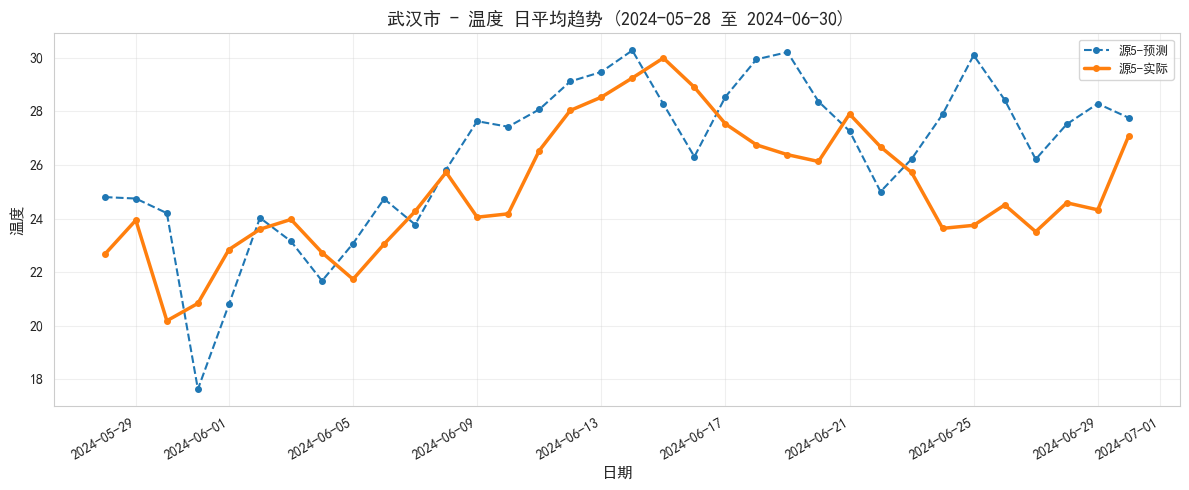

In [76]:
plot_weather_timeseries(
    df_weather_simplified,
    city="武汉市",
    weather_type="温度",
    data_sources=['源1', '源2', '源3', '源4', '源5', '源6', '源7'],
    plot_type='both',
    start_date='2024-05-28',
    end_date='2024-06-30'
)

In [77]:
# 选择城市和气象类型
city = "武汉市"  # 可选: 孝感市, 宜昌市, 武汉市, 荆州市等
weather_type = "温度"  # 可选: 温度, 风速, 总云量, 相对湿度, 压强, 辐照度, 降雨量

# 分析数据
results = analyze_weather_data(df_weather_simplified, city, weather_type)
'''
# 导出结果到Excel
if results:
    output_path = f"../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"
    export_results_to_excel(results, output_path)
'''

找到以下列: ['武汉市-温度-源5-预测', '武汉市-温度-源5-实际']

预测数据源: ['武汉市-温度-源5-预测']
实际数据源: ['武汉市-温度-源5-实际']

1. 预测数据源之间的比较

2. 预测与实际数据之间的比较

武汉市-温度-源5-预测 vs 武汉市-温度-源5-实际:
  Spearman相关系数: 0.9376 (p值: 0.0000)
  RMSE: 3.5303
  sMAPE: 27.04%
  样本数: 7272


'\n# 导出结果到Excel\nif results:\n    output_path = f"../results/logs/{city}_{weather_type}_数据源对比分析.xlsx"\n    export_results_to_excel(results, output_path)\n'

In [78]:
def analyze_dayahead_vs_realtime(df, feature_pairs=None):
    """
    计算实时和日前特征之间的Spearman相关系数和sMAPE
    
    参数:
        df: DataFrame，包含实时和日前数据
        feature_pairs: 字典，格式为 {'实时列名': '日前列名'}，如果为None则自动匹配
    
    返回:
        results_df: 包含分析结果的DataFrame
    """
    
    # 如果没有提供特征对，自动匹配（根据列名规则）
    if feature_pairs is None:
        # 找出所有-实时和-日前列
        realtime_cols = [col for col in df.columns if '-实时' in col or '实时' in col]
        dayahead_cols = [col for col in df.columns if '-日前' in col or '日前' in col]
        
        feature_pairs = {}
        for rt_col in realtime_cols:
            # 尝试找到对应的日前列
            for da_col in dayahead_cols:
                # 提取特征名称（去掉-实时/-日前后缀）
                rt_feature = rt_col.replace('-实时', '').replace('实时', '').replace('（元/MWh）', '')
                da_feature = da_col.replace('-日前', '').replace('日前', '').replace('（元/MWh）', '')
                
                if rt_feature == da_feature and '价格' not in rt_col:
                    feature_pairs[rt_col] = da_col
                    break
    
    results = []
    
    print("="*70)
    print("实时数据 vs 日前数据 相关性分析")
    print("="*70)
    
    for realtime_col, dayahead_col in feature_pairs.items():
        if realtime_col not in df.columns or dayahead_col not in df.columns:
            print(f"\n⚠️ 跳过: {realtime_col} 或 {dayahead_col} 不存在")
            continue
        
        # 获取有效数据（去除缺失值）
        valid_data = df[[realtime_col, dayahead_col]].dropna()
        
        if len(valid_data) < 2:
            print(f"\n⚠️ {realtime_col} vs {dayahead_col}: 有效样本不足")
            continue
        
        # 计算Spearman相关系数
        corr, p_value = spearmanr(valid_data[realtime_col], valid_data[dayahead_col])
        # 计算sMAPE（以实时为真实值，日前为预测值）
        smape = calculate_smape(valid_data[realtime_col], valid_data[dayahead_col])
        
        result = {
            '实时特征': realtime_col,
            '日前特征': dayahead_col,
            'Spearman相关系数': round(corr, 4),
            'P值': round(p_value, 4),
            'sMAPE(%)': round(smape, 2),
            '样本数': len(valid_data)
        }
        results.append(result)
        
        # 打印结果
        print(f"\n【{realtime_col}】 vs 【{dayahead_col}】")
        print(f"  Spearman相关系数: {corr:.4f} (p值: {p_value:.4f})")
        print(f"  sMAPE: {smape:.2f}%")
    
    # 转换为DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

results = analyze_dayahead_vs_realtime(df_market)

实时数据 vs 日前数据 相关性分析

【系统负荷-实时】 vs 【系统负荷-日前】
  Spearman相关系数: 0.9526 (p值: 0.0000)
  sMAPE: 4.94%

【风电出力-实时】 vs 【风电出力-日前】
  Spearman相关系数: 0.9142 (p值: 0.0000)
  sMAPE: 31.15%

【光伏出力-实时】 vs 【光伏出力-日前】
  Spearman相关系数: 0.9305 (p值: 0.0000)
  sMAPE: 97.45%

【水电出力-实时】 vs 【水电出力-日前】
  Spearman相关系数: 0.9393 (p值: 0.0000)
  sMAPE: 8.68%

【联络线计划-实时】 vs 【联络线计划-日前】
  Spearman相关系数: 0.9029 (p值: 0.0000)
  sMAPE: 21.34%

【非市场化机组出力-实时】 vs 【非市场化机组出力-日前】
  Spearman相关系数: 0.9461 (p值: 0.0000)
  sMAPE: 7.54%


In [79]:
# 用日前数据填充实时数据的缺失值（实时价格除外）
def fill_realtime_with_day_ahead(df_market):
    """
    用日前数据填充对应的实时数据缺失值
    注意：平均出清价格-实时 不填充，保持独立
    """
    # 定义需要填充的列对（实时列: 日前列）
    fill_pairs = {
        '水电出力-实时': '水电出力-日前',
        '风电出力-实时': '风电出力-日前',
        '联络线计划-实时': '联络线计划-日前',
        '系统负荷-实时': '系统负荷-日前',  
        '非市场化机组出力-实时': '非市场化机组出力-日前',  
    }
    
    fill_count = {}
    
    for realtime_col, dayahead_col in fill_pairs.items():
        if realtime_col in df_market.columns and dayahead_col in df_market.columns:
            # 统计填充前的缺失值数量
            missing_before = df_market[realtime_col].isnull().sum()
            
            # 用日前数据填充实时数据的缺失值
            df_market[realtime_col] = df_market[realtime_col].fillna(df_market[dayahead_col])
            
            # 统计实际填充的数量
            missing_after = df_market[realtime_col].isnull().sum()
            filled_count = missing_before - missing_after
            
            fill_count[realtime_col] = filled_count
    
    # 打印汇总
    print("\n" + "="*50)
    print("填充汇总：")
    total_filled = sum(fill_count.values())
    print(f"总共填充了 {total_filled} 个缺失值")
    print("="*50)
    
    return df_market

# 执行填充
df_market = fill_realtime_with_day_ahead(df_market)

# 查看填充后的缺失值情况
print("\n填充后的缺失值统计：")
missing_after = df_market.isnull().sum()
missing_info = pd.DataFrame({
    '缺失数量': missing_after,
    '缺失比例(%)': (missing_after / len(df_market) * 100).round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)
display(missing_info)


填充汇总：
总共填充了 2457 个缺失值

填充后的缺失值统计：


,缺失数量,缺失比例(%)
平均出清价格-日前（元/MWh）,216,2.97
光伏出力-实时,96,1.32
光伏出力-日前,48,0.66
风电出力-日前,48,0.66
联络线计划-日前,48,0.66
平均出清价格-实时（元/MWh）,48,0.66


In [ ]:
columns_to_drop = ['水电出力-日前', '系统负荷-日前', '非市场化机组出力-日前',
 '平均出清价格-日前（元/MWh）', '风电出力-日前', '光伏出力-日前', '联络线计划-日前',
  '日期', '时段', '时间戳', '年']
# df_market_simplified = df_market.drop(columns=columns_to_drop, inplace=True)
# df_merged = pd.concat([df_weather, df_market_simplified], axis=1)
# df_merged.to_csv('../data/processed/processed_data.csv', index=False)
df_merged = pd.read_csv('../data/processed/processed_data.csv')
print('简化后的市场总表与气象总表合并后的数据集形状：')
print(df_merged.shape)


简化后的市场总表与气象总表合并后的数据集形状：
(7272, 318)


In [83]:
# 查看合并后的缺失值情况
print("\n合并后的缺失值统计：")
missing_after = df_merged.isnull().sum()
missing_info = pd.DataFrame({
    '缺失数量': missing_after,
    '缺失比例(%)': (missing_after / len(df_merged) * 100).round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)
display(missing_info)


合并后的缺失值统计：


,缺失数量,缺失比例(%)
黄冈市-总云量-源2-预测,922,12.68
武汉市-总云量-源2-预测,907,12.47
荆门市-总云量-源2-预测,896,12.32
孝感市-总云量-源2-预测,896,12.32
随州市-总云量-源2-预测,887,12.20
...,...,...
荆州市-温度-源7-实际,77,1.06
武汉市-风速-源7-实际,77,1.06
武汉市-温度-源7-实际,77,1.06
武汉市-相对湿度-源7-实际,77,1.06
